In [85]:
import sys
sys.path.insert(0, '../../gofher')

import os
import matplotlib.image as mpimg
from astropy.visualization import make_lupton_rgb

from gofher import run_gofher, run_gofher_with_parameters
from visualize import visualize
from file_helper import write_csv,check_if_folder_exists_and_create, construct_csv_dict
from spin_parity import read_spin_parity_galaxies_label_from_csv, standardize_galaxy_name
from sparcfire import read_sparcfire_galaxy_csv, get_ref_band_and_gofher_params
from matrix import create_centered_mesh_grid, create_minor_axis_angle_matrix, create_dist_matrix

from fits import write_fits, read_fits
from photutils.aperture import CircularAperture, aperture_photometry

In [86]:
survery_to_use = "sdss" #Note: for sdss we are not using u do to poor quality

BANDS_IN_ORDER = ['g','r','i','z'] #Important: Must stay in order of BLUEST to REDDEST Waveband (Editting this will cause gofher to no longer correctly evaluate redder side of galaxy)
REF_BANDS_IN_ORDER = ['r','i','z','g'] #The prefernce each waveband being choosen as refernce band from highest priority to lowest priority

In [87]:
#figures_to_run_on = ["table2","table3","table4","table5"]
#figures_to_run_on = ["figure9"]

figures_to_run_on = ["table2","table3","table4","table5","figure9"]


output_folder_dict = {"table2":"figure8",
                      "table3":"figure9",
                      "table4":"figure10",
                      "table5":"figure11",
                      "figure9":"figure9"}

In [88]:
#panstarrs:
bin_size = None #None or a positive integer

#sdss:
#NOTE: sdss needs to flip color image
##bin_size = 4 #should be 4
#Source: "The median seeing of all SDSS imaging data (using the psfWidth metric) is 1.32 arcseconds in the r-band."
#"The pixel size in the Sloan Digital Sky Survey (SDSS) is 0.396 arcseconds per pixel" - https://classic.sdss.org/dr3/instruments/imager/
bin_prior_to_param_fitting = True

In [89]:
generate_verbose_csv = True
generate_ebm_csv = False
generate_params_csv = True
generate_visualization = True
save_visualization = True
generate_gamma_csv = True

In [90]:
#Important: Make sure you update these values:
blur_sdss_fits_folder = "E:\\grad_school\\research\\spin_parity_blurring\\sdss_output"
#blur_sdss_folder = "E:\\grad_school\\research\\spin_parity_blurring\\sparcfire_sdss_output"
blur_sparcfire_folder = "E:\\grad_school\\research\\spin_parity_blurring\\sparcfire_sdss_output"
path_to_output = "C:\\Users\\school\\Desktop\\github\\gofher-data\\sdss\\blur_folder_9"
gofher_labels_folder = "C:\\Users\\school\\Desktop\\github\\gofher-data\\sdss\\sparcfire_0_25"
path_to_catalog_data = "..\\..\\..\\spin-parity-catalog-data"
fits_save_path = "E:\\grad_school\\research\\winter_2026\\blur_fits_save_path_unblurred_ellipse_mask\\"

In [91]:
def get_blur_folder(the_sn,the_psf):
    return "psf_{}_background_{}".format(str(the_psf),str(the_sn))

def get_sparcfire_csv_path(figure_to_run_on): #temp
    #temp procedure for blending two:
    if figure_to_run_on == "figure9":
        return "C:\\Users\\school\\Desktop\\cross_id\\sdss_mosaic_construction\\SpArcFiRe_output\\figure9\\G.out\\galaxy.csv"
    else:
        return "C:\\Users\\school\\Desktop\\cross_id\\sdss_mosaic_construction\\SpArcFiRe_output\\{}\\G.out\\galaxy.csv".format(figure_to_run_on)

In [92]:
def construct_image(gal):
    for band in ["g","r","i"]:
        if band not in gal.bands:
            the_keys = list(gal.bands.keys())
            return gal[the_keys[0]].data

    g = gal.bands["g"].data
    r = gal.bands["r"].data*0.8
    i = gal.bands["i"].data*0.7

    return make_lupton_rgb(i, r, g, Q=10, stretch=0.3, minimum=0.0)

In [93]:

folder_map = {"table2":"figure8",
              "table3":"figure9",
              "table4":"figure10",
              "table5":"figure11",
              "figure9":"table3"}

def get_path_to_catalog_csv(figure_to_run_on):
    return os.path.join(path_to_catalog_data,"catalog","{}.csv".format(figure_to_run_on))

def get_paper_dark_side_labels(figure_to_run_on):
    #temp procedure for blending two:
    if figure_to_run_on == "table3":
        figure_to_run_on = "figure9"
    return read_spin_parity_galaxies_label_from_csv(get_path_to_catalog_csv(figure_to_run_on))

def get_fits_path(name,band,blur_folder,figure_to_run_on):
    """the file path of where existing fits files can be found"""
    return os.path.join(blur_sdss_fits_folder,blur_folder,figure_to_run_on,name,"{}_{}.fits".format(name,band))

def get_galaxy_list(blur_folder,figure_to_run_on):
    the_directory = os.path.join(blur_sdss_fits_folder,blur_folder,figure_to_run_on)
    return os.listdir(the_directory)

def get_sparcfire_path(blur_folder,figure_to_run_on): #temp
    return os.path.join(blur_sparcfire_folder,blur_folder,figure_to_run_on,"G.out","galaxy.csv")

def get_path_to_output(blur_folder, figure_to_run_on):
    if figure_to_run_on in folder_map:
        figure_to_run_on = folder_map[figure_to_run_on]
    return os.path.join(path_to_output,blur_folder)

def get_fits_save_path(blur_folder,figure_to_run_on,name):
    if figure_to_run_on != "figure9" and figure_to_run_on in folder_map:
        figure_to_run_on = folder_map[figure_to_run_on]
    return os.path.join(fits_save_path,blur_folder,figure_to_run_on,name)


def get_gofher_labels(figure_to_run_on):
    #if condition because I already combined them
    if figure_to_run_on != "figure9" and figure_to_run_on in folder_map:
        figure_to_run_on = folder_map[figure_to_run_on]
    path = os.path.join(gofher_labels_folder,f"{figure_to_run_on}_verbose.csv")
    return construct_csv_dict(path,"name","GOFHER_label")

In [94]:
def get_visulization_save_path_folder(name,figure_to_run_on, blur_folder):
    if figure_to_run_on in folder_map:
        figure_to_run_on = folder_map[figure_to_run_on]
    return os.path.join(path_to_output,blur_folder,figure_to_run_on)

def _ensure_path_exists(path_to_output,make_ouput_folder_if_not_exists=True):
    if not make_ouput_folder_if_not_exists:
        raise ValueError("The path output is not found {} - make sure you update path_to_output".format(path_to_output))
    
    if not os.path.exists(path_to_output):
        os.makedirs(path_to_output)

In [95]:
#IMPOTRTANT: Assumes fits are square images, and all bands are same size
def get_original_fits_shape(folder,name):
    pass

def get_new_fits_shape(folder,blur_folder,name):
    print("here",folder)
    if folder == "figure8":
        folder = "table2"
    elif folder == "figure9":
        folder = "figure9"
    elif folder == "figure10":
        folder = "table4"
    elif folder == "figure11":
        folder = "table5"
    elif folder == "table3":
        folder = "table3"
    folder_path = os.path.join(blur_sdss_fits_folder,blur_folder,folder,name)
    for file in os.listdir(folder_path):
        if file.split(".")[-1] == "fits":
            return read_fits(os.path.join(folder_path,file)).shape
    return None

def get_original_shape(folder,name):
    if folder == "table2":
        folder = "figure8"
    elif folder == "table3":
        folder = "figure9"
    elif folder == "table4":
        folder = "figure10"
    elif folder == "table5":
        folder = "figure11"
    base = "C:\\Users\\school\\Desktop\\github\\spin-parity-catalog-data\\sdss"
    folder_path = os.path.join(base,folder,name)
    for file in os.listdir(folder_path):
        print(file)
        if file.split(".")[-1] == "fits":
            pa = os.path.join(folder_path,file)
            return read_fits(pa).shape
    return None

def get_color_image_path(folder,name):
    if folder == "table2":
        folder = "figure8"
    elif folder == "table3":
        folder = "figure9"
    elif folder == "table4":
        folder = "figure10"
    elif folder == "table5":
        folder = "figure11"
    base = "C:\\Users\\school\\Desktop\\github\\spin-parity-catalog-data\\sdss"
    return os.path.join(base,folder,name,"{}_color.png".format(name))

In [96]:
import numpy as np

def estimate_snr(gal):
    """
    aperture = CircularAperture((gal.gofher_params.x, gal.gofher_params.y), r=gal.gofher_params.a/2)
    phot_table = aperture_photometry(gal.bands[gal.ref_band].data, aperture)
    signal = phot_table['aperture_sum'][0]
    #print(signal)

    sky_background = gal.bands[gal.ref_band].data[0:50, 0:50] # Placeholder: select a patch of sky
    noise = np.std(sky_background)
    n_pix = aperture.area
    snr = signal / (noise * np.sqrt(n_pix))
    #print(snr)
    #return
    """
    snr_dict = {}

    for band in gal.bands:
        data = gal.bands[band].data
        aperture = CircularAperture((gal.gofher_params.x, gal.gofher_params.y), r=gal.gofher_params.a/2)
        phot_table = aperture_photometry(gal.bands[gal.ref_band].data, aperture)
        signal = phot_table['aperture_sum'][0]

        sky_background = gal.bands[gal.ref_band].data[0:50, 0:50] #random patch of sky: assuming uniform sky
        noise = np.std(sky_background)
        n_pix = aperture.area
        snr = signal / (noise * np.sqrt(n_pix))

        snr_dict[band] = snr

    """
    el_mask = gal.create_ellipse()
    not_el_mask = np.logical_not(el_mask)
    el_mask_size = np.sum(el_mask)

    for band in gal.bands:
        data = gal.bands[band].data
        signal = np.sum(data[el_mask])
        noise = np.std(data[not_el_mask])
        snr = signal/(noise*np.sqrt(el_mask_size))
        snr_dict[band] = snr
    """
    return snr_dict


In [97]:
def run_gofher_on_catalog(figure_to_run_on,blur_folder,bulge_disk_f=1.0):
    #paper_labels = get_paper_dark_side_labels(figure_to_run_on)
    gofher_labels = get_gofher_labels(figure_to_run_on)
    sparcfire_gals = read_sparcfire_galaxy_csv(get_sparcfire_csv_path(figure_to_run_on))

    verbose_header = []
    verbose_rows = []

    params_header = []
    params_rows = []

    gamma_header = []
    gamma_rows = []

    i = 1

    snr_ratio_dict = {}

    path_to_output = get_path_to_output(blur_folder, figure_to_run_on)
    #print(path_to_output)
    #return
    _ensure_path_exists(path_to_output)

    def get_fits_path_cat(name,band):
        """the file path of where existing fits files can be found"""
        return get_fits_path(name,band,blur_folder,figure_to_run_on)

    galaxies = get_galaxy_list(blur_folder,figure_to_run_on)
    for name in galaxies:

        if standardize_galaxy_name(name) not in gofher_labels:
            print("skipping",name)
            continue

        print(name, i,"of",len(galaxies))

        try:
            fits_path = get_fits_save_path(blur_folder,figure_to_run_on,name)
            _ensure_path_exists(fits_path)
            

            paper_label = gofher_labels[standardize_galaxy_name(name)]

            ref_band, inital_gofher_params = get_ref_band_and_gofher_params(sparcfire_gals[name],REF_BANDS_IN_ORDER,bulge_disk_f)
            original_shape = get_original_shape(figure_to_run_on,name)
            new_shape = get_new_fits_shape(figure_to_run_on,blur_folder,name)

            if original_shape is None or new_shape is None:
                print("Skipping: size")
                continue
            
            s = new_shape[0]/original_shape[0]
            inital_gofher_params.a *= s
            inital_gofher_params.b *= s
            inital_gofher_params.x *= s
            inital_gofher_params.y *= s

            #gal.gofher_params = inital_gofher_params
            #color_image = color = mpimg.imread(get_color_image_path(figure_to_run_on,name))
            gal = run_gofher_with_parameters(name,get_fits_path_cat,BANDS_IN_ORDER,ref_band,inital_gofher_params,paper_label=paper_label)
            gal_snr_dict = estimate_snr(gal)

            for band in gal_snr_dict:
                if band not in snr_ratio_dict:
                    snr_ratio_dict[band] = []
                snr_ratio_dict[band].append(gal_snr_dict[band])
            #break
            

        except Exception as e:
            print(e)
        i += 1
        
    return snr_ratio_dict

IC1683 1 of 112
IC1683_color.png
IC1683_g.fits
here table2
IC1755 2 of 112
IC1755_color.png
IC1755_g.fits
here table2
IC2101 3 of 112
IC2101_color.png
IC2101_g.fits
here table2
construct_band: fits_path E:\grad_school\research\spin_parity_blurring\sdss_output\psf_4.0_background_0.0625\table2\IC2101\IC2101_i.fits does not exist
IC5376 4 of 112
IC5376_color.png
IC5376_g.fits
here table2
skipping MCG-02-02-030
skipping MCG-02-51-004
NGC1035 5 of 112
NGC1035_color.png
NGC1035_g.fits
here table2
NGC1056 6 of 112
NGC1056_color.png
NGC1056_g.fits
here table2
construct_band: fits_path E:\grad_school\research\spin_parity_blurring\sdss_output\psf_4.0_background_0.0625\table2\NGC1056\NGC1056_g.fits does not exist
construct_band: fits_path E:\grad_school\research\spin_parity_blurring\sdss_output\psf_4.0_background_0.0625\table2\NGC1056\NGC1056_i.fits does not exist
construct_band: fits_path E:\grad_school\research\spin_parity_blurring\sdss_output\psf_4.0_background_0.0625\table2\NGC1056\NGC1056_z.

C:\Users\school\AppData\Local\Temp\ipykernel_32276\2852361354.py:37: RuntimeWarning: invalid value encountered in log
  return a * np.log(x - x0) / np.log(base) + c


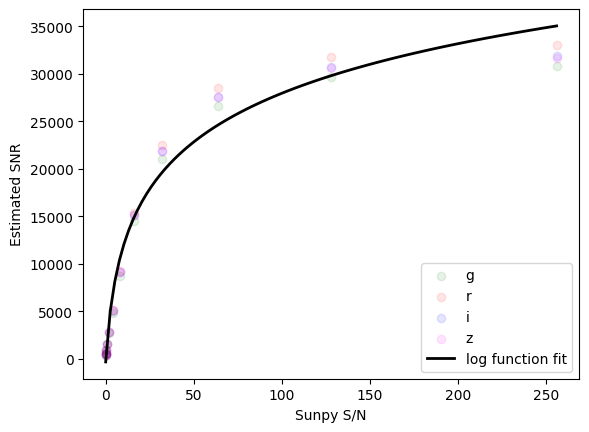

In [98]:
#if not os.path.exists(path_to_catalog_data):
#    raise ValueError("The path to the catalog is not found {} - make sure you update path_to_catalog_data".format(path_to_catalog_data))

#sn_list = [0.5, 0.25,0.125,0.0625, 1, 2, 4, 8, 16, 32, 64, 128, 256]
#sn_list = [0.0625, 256]
sn_list = [0.0625,0.125,0.25,0.5,1,2,4,8,16,32,64,128,256]
psf_list = [4.0] #, 5.6, 8.0, 11.3,16.0, 22.6, 32.0, 45.2, 64.0, 90.5, 128.0]

sn_to_snr_dict = {}

for sn in sn_list:
    for psf in psf_list:
        all_snr_dict = {}
        for figure_to_run_on in figures_to_run_on:
            blur_folder = get_blur_folder(sn,psf)
            snr_ratio_dict = run_gofher_on_catalog(figure_to_run_on,blur_folder,bulge_disk_f=0.25)
            for band in snr_ratio_dict: 
                if sn not in sn_to_snr_dict:
                    sn_to_snr_dict[sn] = {}
                if band not in sn_to_snr_dict[sn]:    
                    sn_to_snr_dict[sn][band] = []
                sn_to_snr_dict[sn][band].append(snr_ratio_dict[band])
            break
        break
    #break



import matplotlib.pyplot as plt

import numpy as np
from scipy.optimize import curve_fit

# y = a * log_base(x - x0) + c
# Written as: a * ln(x - x0) / ln(base) + c
def log_func(x, a, base, x0, c):
    return a * np.log(x - x0) / np.log(base) + c


log_fit_x = []
log_fit_y = []
add_labels = True
for sn in sn_to_snr_dict:
    for band in sn_to_snr_dict[sn]:
        sn_to_snr_dict[sn][band] = np.array(sn_to_snr_dict[sn][band])
        mean = sn_to_snr_dict[sn][band].mean()
        std = sn_to_snr_dict[sn][band].std()
        cmap = {'g':'green','r':'red','i':'blue','z':'magenta'}
        #x = np.ones(sn_to_snr_dict[sn][band].shape)*sn
        #y = sn_to_snr_dict[sn][band]
        #print(len(x),len(y))
        #plt.scatter(x,y,c=cmap[band],alpha=0.1)
        if add_labels:
            plt.scatter(sn,mean,c=cmap[band],alpha=0.1,label=band)
        else:
            plt.scatter(sn,mean,c=cmap[band],alpha=0.1)
        log_fit_x.append(sn)
        log_fit_y.append(mean)
        #plt.errorbar(sn,mean,yerr=std)
        plt.xlabel("Sunpy S/N")
        plt.ylabel("Estimated SNR")
        #plt.title(band)
        plt.legend()
        #break
    add_labels = False

# Assume x_data and y_data are defined
# p0 = [a, base, x0, c]
p0 = [1.0, 10.0, 0.0, 0.0]
popt, pcov = curve_fit(log_func,log_fit_x, log_fit_y, p0=p0)
a_fit, base_fit, x0_fit, c_fit = popt


x = np.linspace(0.0625, 256.0, 100)
y = log_func(x, a_fit, base_fit, x0_fit, c_fit)
plt.plot(x, y, label='log function fit', lw=2, alpha=1.0, color='black')

#plt.show()
plt.legend()

plt.savefig("log_fit.png",dpi=300,bbox_inches='tight')

In [99]:
print(a_fit, base_fit, x0_fit, c_fit)

50.72839439517614 1.006636623450039 -2.5002040942865813 -7544.232205845531
